<a href="https://colab.research.google.com/github/johnphiliptan243-source/Neural-Network/blob/main/Neural_Network_NARX_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

def generate_litho_data(steps=1000):
    t = np.linspace(0, 10, steps)

    # 1. Target Pathway (The 'Map' input)
    # Simulating a scanning movement in X and Y
    path_x = np.sin(t)
    path_y = np.cos(t)

    # 2. External Noise (Heat + Vibration)
    thermal_drift = 0.05 * np.sin(0.1 * t) # Slow drift
    vibration = np.random.normal(0, 0.01, steps) # High-freq jitter

    # 3. Simulated Actual Position (Target + Noise + Drift)
    # In a real machine, the "Error" is what we want to fix
    actual_x = path_x + thermal_drift + vibration

    # Create DataFrame
    data = pd.DataFrame({
        'target_x': path_x,
        'target_y': path_y,
        'thermal_input': thermal_drift,
        'vibration_input': vibration,
        'actual_x': actual_x
    })
    return data

df = generate_litho_data()
print("Synthetic Lithography Data Ready!")

Synthetic Lithography Data Ready!


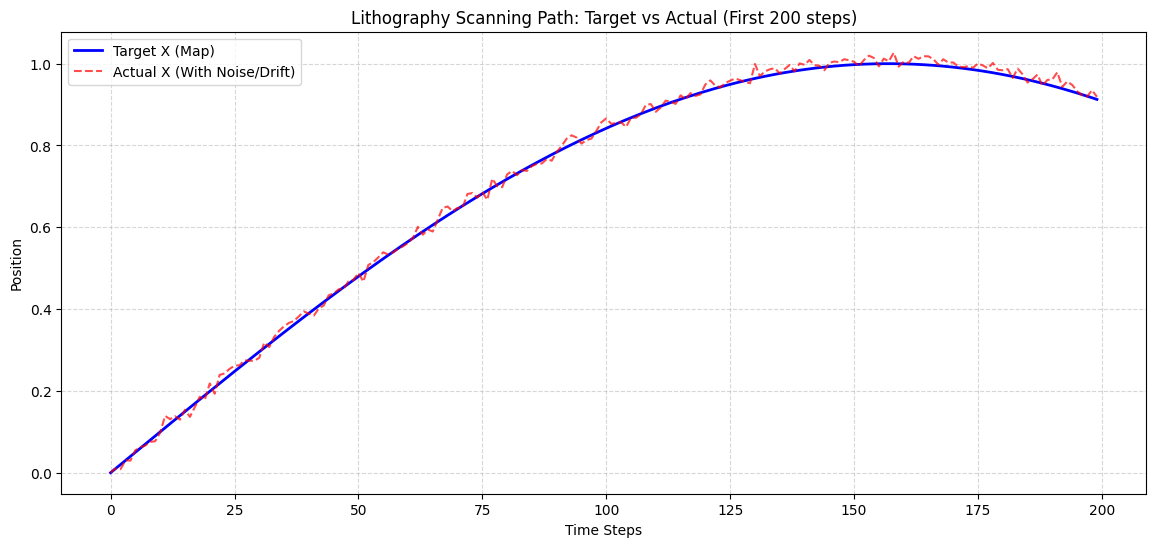

,target_x,actual_x
0,0.000000,0.000383
1,0.010010,0.010380
2,0.020019,0.008540
3,0.030026,0.030556
4,0.040029,0.029433


In [ ]:
import matplotlib.pyplot as plt

# Plotting Target X vs Actual X
plt.figure(figsize=(14, 6))
plt.plot(df['target_x'][:200], label='Target X (Map)', color='blue', linewidth=2)
plt.plot(df['actual_x'][:200], label='Actual X (With Noise/Drift)', color='red', linestyle='--', alpha=0.7)

plt.title('Lithography Scanning Path: Target vs Actual (First 200 steps)')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

# Displaying the raw values for the first few rows
display(df[['target_x', 'actual_x']].head())

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from sklearn.preprocessing import StandardScaler

# 1. Windowing Function (The "Tapped Delay Line" logic)
def create_narx_dataset(data, lags=5):
    X, y = [], []
    # We use 'lags' number of previous steps to predict the next correction
    for i in range(lags, len(data)):
        # Exogenous inputs (Noise + Path) + Feedback (Previous Positions)
        # Flattening the previous 'n' steps into one long input vector
        window = data.iloc[i-lags:i].values.flatten()
        X.append(window)

        # Target: The 6-DoF correction needed at the current step 'i'
        # (For this simulation, let's assume we are predicting the 'actual_x' error)
        y.append(data.iloc[i]['target_x'] - data.iloc[i]['actual_x'])

    return np.array(X), np.array(y)

# 2. Data Preparation
lags = 10 # Looking back 10 steps (~10ms in real lithography)
X, y = create_narx_dataset(df, lags=lags)

# Split into Training and Test
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# 3. Defining the NARX Architecture
model_narx = Sequential([
    Input(shape=(X_train.shape[1],)), # Input size = (features * lags)
    Dense(128, activation='tanh'),   # Tanh is preferred for mechanical oscillations
    Dense(64, activation='tanh'),
    Dropout(0.2),                    # Prevents overfitting to specific noise patterns
    Dense(1)                         # Output: The correction for X (expand to 6 for 6-DoF)
])

model_narx.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 4. Training (Open-Loop / Series-Parallel)
history = model_narx.fit(X_train, y_train,
                         epochs=50,
                         batch_size=32,
                         validation_split=0.1,
                         verbose=1)



Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 0.2782 - mae: 0.4096 - val_loss: 0.0108 - val_mae: 0.0857
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0581 - mae: 0.1935 - val_loss: 0.0114 - val_mae: 0.0991
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0284 - mae: 0.1330 - val_loss: 2.9538e-04 - val_mae: 0.0131
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0179 - mae: 0.1051 - val_loss: 3.1923e-04 - val_mae: 0.0150
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0118 - mae: 0.0885 - val_loss: 0.0062 - val_mae: 0.0781
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0075 - mae: 0.0692 - val_loss: 0.0046 - val_mae: 0.0666
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0048 - mae: 0.0545 - val_loss: 0.0010 - val_mae: 0.0293
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0024 - mae: 0.0381 - val_loss: 5.8909e-04 - val_mae: 0.0219
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0

In [ ]:
import os
import pandas as pd

# 1. Define your project path in Google Drive
project_folder = '/content/drive/MyDrive/Lithography_Project'

# 2. Create the folder if it doesn't exist
if not os.path.exists(project_folder):
    os.makedirs(project_folder)
    print(f'Created folder: {project_folder}')

# 3. Save the trained model
model_path = os.path.join(project_folder, 'narx_model_v1.keras')
model_narx.save(model_path)
print(f'Model saved to: {model_path}')

# 4. Save the training history to a CSV
history_df = pd.DataFrame(history.history)
history_path = os.path.join(project_folder, 'training_history_v1.csv')
history_df.to_csv(history_path, index=False)
print(f'History saved to: {history_path}')

Created folder: /content/drive/MyDrive/Lithography_Project
Model saved to: /content/drive/MyDrive/Lithography_Project/narx_model_v1.keras
History saved to: /content/drive/MyDrive/Lithography_Project/training_history_v1.csv
